# 01 · From Derivatives to a Backprop Graph

Building up to backpropagation from the definition of a derivative: first
estimating slopes numerically, then wrapping scalars in a `Value` object that
records how it was computed, and finally walking that graph backwards by hand
to get every gradient.

Working through [Andrej Karpathy's *Neural Networks: Zero to Hero*](https://karpathy.ai/zero-to-hero.html),
lecture 1 (micrograd).

> Run top to bottom. Several cells rebind names that earlier cells define;
> see the notes at the end.

## Setup

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## A function to differentiate

A simple quadratic, chosen because its derivative is easy to verify by hand:

$$f(x) = 3x^2 - 4x + 5 \qquad f'(x) = 6x - 4$$

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

## What the function looks like

Plotting over $[-5, 5)$ shows the parabola and, visually, where the slope is
negative, zero, and positive.

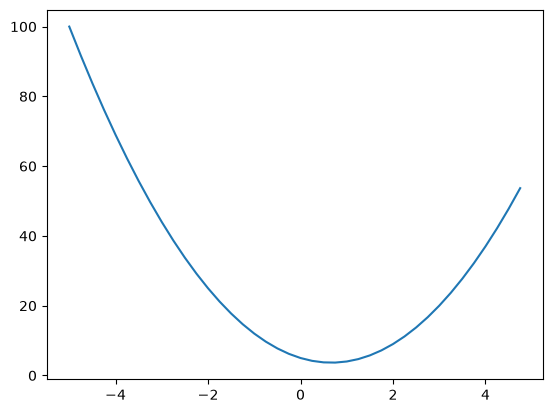

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

## The derivative, numerically

The definition of a derivative is a limit:

$$f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}$$

A computer can't take a limit, so it takes a small $h$ instead. At $x = 3$ the
analytic answer is $6(3) - 4 = 14$, so the numerical estimate should land just
beside it, and the gap is the price of $h$ not actually being zero.

In [5]:
h = 0.001
x = 3.0
(f(x + h) - f(x))/h #slope function

14.00300000000243

`14.003` against an exact `14`. That error is the whole story of numerical
differentiation: shrink $h$ and the estimate improves, until floating-point
cancellation in `f(x + h) - f(x)` starts making it worse again.

Backpropagation exists to avoid this tradeoff entirely, computing exact
derivatives analytically, one operation at a time, instead of estimating them.

**Next:** building the `Value` object that tracks those operations.

---

## Derivatives with more than one input

The same numerical trick, on an expression with three inputs:

$$d = a \cdot b + c$$

Each input has its own derivative. To get one, nudge that input by $h$, hold
the others fixed, and measure how much $d$ moved.

In [6]:
a = 2.0
b = -3.0
c = 10.0
d = a*b+c
print(d)

4.0


In [7]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b+c
a += h
d2 = a*b+c

print('d1:', d1)
print('d2:', d2)
print('slope:', (d2-d1)/h)

d1: 4.0
d2: 3.999699999999999
slope: -3.000000000010772


Nudging `a` gives a slope of about $-3$, which is exactly `b`. That's the
analytic answer: $\partial d / \partial a = b$. Nudging `c` would give $1$,
and nudging `b` would give `a`.

Doing this for every input of every intermediate value is the brute-force way
to get gradients. It costs one full forward pass per input, and each answer
carries the same $h$-sized error as before. The rest of this notebook builds
the machinery that replaces it.

---

## The `Value` object

A scalar that remembers where it came from, and how to push a gradient back
through the operation that made it. Four pieces beyond the number itself:

- **`_prev`**: the operands this value was computed from
- **`_op`**: which operation produced it
- **`grad`**: the derivative of the final output with respect to this node
- **`_backward`**: a closure that takes this node's `grad` and adds each
  operand's share to *its* `grad`. A no-op on leaves.

Because `__add__` and `__mul__` are overloaded, ordinary arithmetic builds the
graph as a side effect, and each operation installs the local derivative rule
it will need later. `backward()` then seeds `grad = 1.0` at the root and walks
the graph in reverse topological order, so every node's gradient is complete
before it propagates further.

Note `+=` rather than `=` in each closure: a value used in more than one place
collects a contribution from every path, and those have to sum.

The expression built below:

$$e = a \cdot b \qquad d = e + c \qquad L = d \cdot f$$

In [193]:
class Value: 
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other): # other * self
        return self * other
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
          self.grad += (1 - t**2) * out.grad
        out._backward = _backward
    
        return out

    def backward(self):        
        # topological sort
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

### What actually got recorded

`d._prev` holds the two `Value`s that produced it and `d._op` holds the symbol.
Those parent pointers, followed recursively, *are* the graph; there's no
separate structure holding it.

In [194]:
#a * b , + c
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [195]:
d._op

'+'

---

## Drawing the graph

`trace` does a depth-first walk from the root, collecting every node and edge
by following `_prev`. `draw_dot` renders each value as a record box showing its
label, data, and grad, plus a small circle for each operation feeding into it.

This needs the graphviz **system binary**, not just the Python package:
`brew install graphviz` on macOS.

In [196]:
from graphviz import Digraph

def trace(root):
    #builds a set of all notes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # Left to Right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular record node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            #if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

---

## Backprop by hand

`backward()` can do this automatically now, but working one pass out by hand
first is what makes the closures above legible. The gradients below are
assigned manually. Starting from $\frac{\partial L}{\partial L} = 1$ and walking
backwards through the chain rule:

| node | derivative | value |
|------|------------|-------|
| `L`  | $\partial L/\partial L$                          | `1.0`  |
| `d`  | $\partial L/\partial d = f$                       | `-2.0` |
| `f`  | $\partial L/\partial f = d$                       | `4.0`  |
| `c`  | $\partial L/\partial c = \partial L/\partial d$  | `-2.0` |
| `e`  | $\partial L/\partial e = \partial L/\partial d$  | `-2.0` |
| `a`  | $\partial L/\partial a = (\partial L/\partial e) \cdot b$ | `6.0`  |
| `b`  | $\partial L/\partial b = (\partial L/\partial e) \cdot a$ | `-4.0` |

Two patterns fall out, and they're the ones the automated version encodes:

- **Addition distributes the gradient unchanged.** `d = e + c`, so `e` and `c`
  both inherit `d.grad` as-is.
- **Multiplication routes each operand the *other's* value**, scaled by the
  output's gradient. `e = a * b`, so `a` gets `e.grad * b` and `b` gets
  `e.grad * a`.

Redrawing the graph now shows real numbers in every `grad` field.

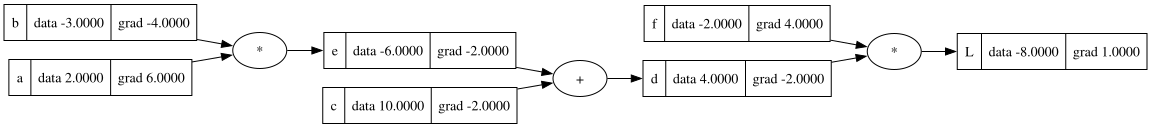

In [197]:
c.grad = -2.0
e.grad = -2.0
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
a.grad = (-2.0 * -3.0)
b.grad = (-2.0 * 2.0)
L.label = 'L'

draw_dot(L)


---

## A squashing function

Linear operations alone can only produce linear functions, however many are
stacked. $\tanh$ is the nonlinearity that fixes that: it maps all of
$\mathbb{R}$ into $(-1, 1)$, flat at the extremes and steepest at zero.

Its derivative is what makes it cheap to backprop through:

$$\frac{d}{dx}\tanh(x) = 1 - \tanh^2(x)$$

The output value is all that's needed, with no need to keep the input around. That
is exactly what `Value.tanh` closes over.

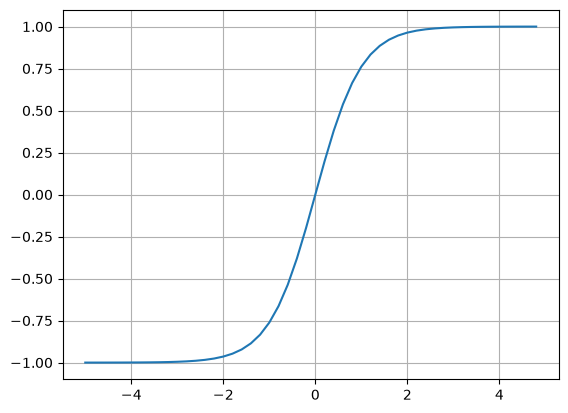

In [198]:
#activation function 
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5, 0.2))); plt.grid();

---

## A single neuron

The first thing resembling a network: two inputs, two weights, a bias, and a
$\tanh$ squash.

$$o = \tanh(x_1 w_1 + x_2 w_2 + b)$$

The bias is set to `6.8813735870195432` so that `n` lands on a round number and
the gradients are easy to eyeball against hand-computed values.

In [199]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

### One call instead of nine

`o.backward()` does what the manual block above did, for the whole graph: seed
the root at `1.0`, sort the nodes so nothing is processed before its consumers,
and run each `_backward` closure in reverse. Every `grad` field in the drawing
below was filled in by that single call.

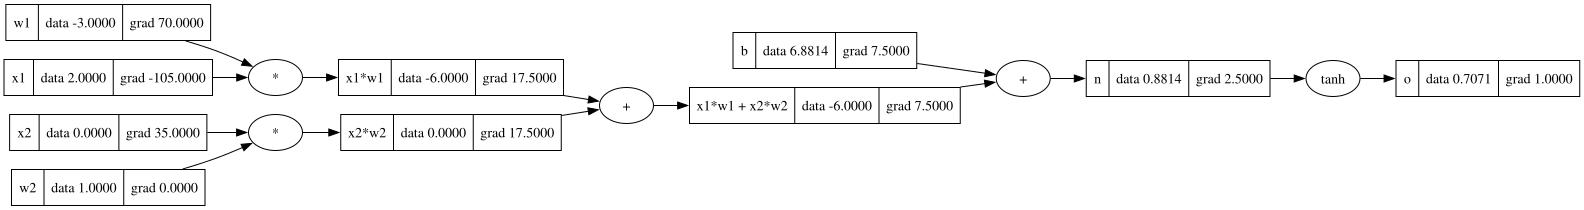

In [205]:
o.backward()
draw_dot(o)